In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:

# === 1️⃣ Đường dẫn gốc ===
base_dir = "/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN"

# === 2️⃣ Danh sách các tập dữ liệu ===
datasets = ["MATRES", "TBD", "TDDAuto", "TDDManu"]

# === 3️⃣ Đọc dữ liệu từ từng file ===
dataframes = {}
for ds in datasets:
    file_path = os.path.join(base_dir, ds, "metrics_by_topk.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        dataframes[ds] = df
    else:
        print(f"⚠️ File not found for {ds}: {file_path}")


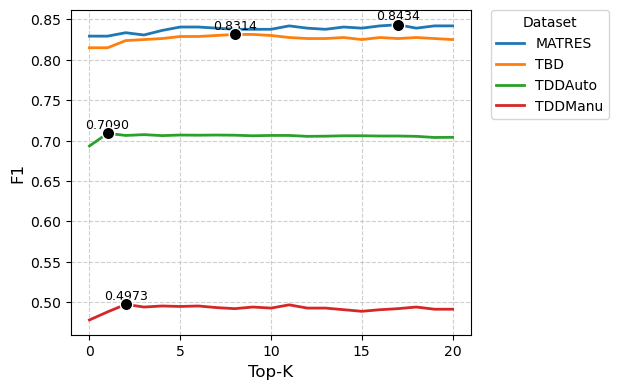

In [3]:
plt.figure(figsize=(8, 4))

for ds, df in dataframes.items():
    # Plot the F1 curve (no markers)
    plt.plot(df["top_k"], df["F1"], linewidth=2, label=ds)
    
    # Find the best F1 point
    best_idx = df["F1"].idxmax()
    best_k = df.loc[best_idx, "top_k"]
    best_f1 = df.loc[best_idx, "F1"]
    
    # Plot only the peak point with a marker
    plt.scatter(best_k, best_f1, s=80, color='black', edgecolors='white', zorder=5)
    
    # Annotate the best point
    plt.text(best_k, best_f1 + 0.0065, f"{best_f1:.4f}", fontsize=9, ha='center')

# plt.title("F1 vs Top-K across Datasets", fontsize=14, fontweight='bold')
plt.xlabel("Top-K", fontsize=12)
plt.ylabel("F1", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Set x-axis ticks every 5
x_min = min(df["top_k"].min() for df in dataframes.values())
x_max = max(df["top_k"].max() for df in dataframes.values())
plt.xticks(range(int(x_min), int(x_max) + 1, 5))

# === Move legend outside the plot ===
plt.legend(
    title="Dataset",
    fontsize=10,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])  # Space for legend

# === 6️⃣ Display the figure ===
plt.show()